# ✈️📱 Flight + App Store Dataset — Full ML Pipeline

**Dataset:** 8050 rows × 21 columns  
**Inspired by:** Flight Price dataset (EasyMyTrip style) + Google Play Store dataset  
**Target Variable:** `ticket_price` → continuous value → Regression problem

---

## 📋 Column Overview

| Column | Type | Mess Injected |
|--------|------|---------------|
| `booking_id` | ID | — |
| `airline` | Categorical | Inconsistent strings (pia, P.I.A, pIA) |
| `source_city` | Categorical | — |
| `destination_city` | Categorical | — |
| `ticket_class` | Categorical | Inconsistent (economy, ECONOMY, eco) |
| `stops` | Categorical | Inconsistent (Non-Stop, nonstop, NON-STOP) |
| `date_of_booking` | String `DD/MM/YYYY` | Needs splitting like flight dataset |
| `dep_time` | String `HH:MM` | Needs splitting into hour/min |
| `duration` | String `Xh Ym` | Needs splitting like flight dataset + NaN |
| `days_until_flight` | Numeric | NaN values |
| `ticket_price` | Numeric — **TARGET** | Outliers (-500, 0, 99999999) |
| `app_name` | Text | — (drop) |
| `app_category` | Categorical | — |
| `app_rating` | Numeric | NaN + outliers (0.0, 6.0, -1.0) |
| `reviews` | String | Non-numeric values (3.0M, 500K) like Playstore |
| `app_size` | String `XM` / `Xk` | Needs M/k conversion like Playstore + NaN |
| `installs` | String `1,000+` | Needs +, comma removal like Playstore + NaN |
| `app_price` | String `$X.XX` | Needs $ removal like Playstore |
| `content_rating` | Categorical | — |
| `last_updated` | String `Month DD, YYYY` | Needs datetime parse → Day/Month/Year |
| `supported_device` | Categorical | — |

---

## 🗺️ Pipeline Steps

| Step | Task |
|------|------|
| 1 | Import Libraries |
| 2 | Load Dataset + Basic Info |
| 3 | EDA — Column by column inspection |
| 4 | Data Cleaning — Fix each column individually |
| 5 | Feature Engineering |
| 6 | Encoding |
| 7 | Outlier Removal (IQR) |
| 8 | Final ML Split (X, y) |

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

---
## 📂 Step 1 — Load Dataset + Basic Info

In [5]:
df = pd.read_csv("flight_app_messy.csv")
df.head()

,booking_id,airline,source_city,destination_city,ticket_class,stops,date_of_booking,dep_time,duration,days_until_flight,...,app_name,app_category,app_rating,reviews,app_size,installs,app_price,content_rating,last_updated,supported_device
0,BK05365,Emirates,Peshawar,New York,Economy,1 stop,13/03/2022,16:45,10h 10m,NaN,...,Gregory Inc App,Social,1.2,3653704,56.1M,"5,000,000+",$1.49,Everyone,"January 5, 2022",iOS
1,BK06261,FlyJinnah,Karachi,Toronto,Business,1 stop,26/06/2024,00:15,3h 45m,6.0,...,Hutchinson Ltd App,Education,1.5,1886603,680k,"500,000+",0,Everyone,"March 3, 2020",Both
2,BK00274,Turkish Airlines,Quetta,New York,First,1 stop,17/10/2024,21:10,NaN,8.0,...,Chan and Sons App,Education,4.4,2234772,768k,"50,000+",$1.49,Teen,"August 6, 2024",Both
3,BK04916,AirBlue,Peshawar,Dubai,Economy,2 stops,15/09/2022,10:45,3h,79.0,...,Smith-Green App,Lifestyle,2.0,1661045,52.1M,"50,000+",$2.99,Mature 17+,"March 1, 2022",iOS
4,BK06581,AirBlue,Multan,London,Economy,non-stop,15/03/2024,12:00,10h 45m,156.0,...,Bonilla Group App,Social,4.6,1228852,63.8M,"100,000+",0,Teen,"January 1, 2023",iOS


In [4]:
df.shape

(8050, 21)

In [5]:
df.columns

Index(['booking_id', 'airline', 'source_city', 'destination_city',
       'ticket_class', 'stops', 'date_of_booking', 'dep_time', 'duration',
       'days_until_flight', 'ticket_price', 'app_name', 'app_category',
       'app_rating', 'reviews', 'app_size', 'installs', 'app_price',
       'content_rating', 'last_updated', 'supported_device'],
      dtype='str')

In [6]:
# See dtypes and null counts
# Observe: almost EVERYTHING is 'object' (string)
# date_of_booking, dep_time, duration, app_size, installs, app_price, last_updated
# all need heavy cleaning — exactly like flight + playstore datasets
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   booking_id         8050 non-null   str    
 1   airline            8050 non-null   str    
 2   source_city        8050 non-null   str    
 3   destination_city   8050 non-null   str    
 4   ticket_class       8050 non-null   str    
 5   stops              8050 non-null   str    
 6   date_of_booking    8050 non-null   str    
 7   dep_time           8050 non-null   str    
 8   duration           7487 non-null   str    
 9   days_until_flight  7487 non-null   float64
 10  ticket_price       8050 non-null   int64  
 11  app_name           8050 non-null   str    
 12  app_category       8050 non-null   str    
 13  app_rating         7487 non-null   float64
 14  reviews            7650 non-null   str    
 15  app_size           7485 non-null   str    
 16  installs           7488 non-null   

In [7]:
# How many missing values per column
df.isnull().sum()

booking_id             0
airline                0
source_city            0
destination_city       0
ticket_class           0
stops                  0
date_of_booking        0
dep_time               0
duration             563
days_until_flight    563
ticket_price           0
app_name               0
app_category           0
app_rating           563
reviews              400
app_size             565
installs             562
app_price              0
content_rating         0
last_updated           0
supported_device       0
dtype: int64

In [8]:
( df.isna().sum() / len(df) * 100).round(2)

booking_id           0.00
airline              0.00
source_city          0.00
destination_city     0.00
ticket_class         0.00
stops                0.00
date_of_booking      0.00
dep_time             0.00
duration             6.99
days_until_flight    6.99
ticket_price         0.00
app_name             0.00
app_category         0.00
app_rating           6.99
reviews              4.97
app_size             7.02
installs             6.98
app_price            0.00
content_rating       0.00
last_updated         0.00
supported_device     0.00
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(50)

---
## 🔍 Step 2 — EDA (Exploratory Data Analysis)

Inspect every column before touching anything

In [ ]:
pd.to_numeric(df["ticket_price"], errors="coerce").describe()
# means it have -ve values as well as some imposible values 

count    8.050000e+03
mean     1.707892e+05
std      3.521145e+06
min     -5.000000e+02
25%      1.975650e+04
50%      2.817550e+04
75%      7.367150e+04
max      1.000000e+08
Name: ticket_price, dtype: float64

In [ ]:
# airline — see all unique values including messy ones
df["airline"].value_counts()
# there are many PIA ... need to fix it 

airline
Turkish Airlines    1395
Emirates            1363
FlyJinnah           1352
SereneAir           1318
AirBlue             1294
PIA                 1268
pIA                   25
pia                   14
P.I.A.                12
P.I.A                  9
Name: count, dtype: int64

In [ ]:
# ticket_class — see messy values like economy, ECONOMY, eco
df["ticket_class"].value_counts()
# same issue with economy class

ticket_class
Economy     5227
Business    2215
First        558
economy       18
eco           18
ECONOMY       14
Name: count, dtype: int64

In [14]:
# stops — see messy values: Non-Stop, nonstop, NON-STOP
df["stops"].value_counts()

stops
1 stop      3184
non-stop    2845
2 stops     1635
3 stops      345
Non-Stop      21
nonstop       13
NON-STOP       7
Name: count, dtype: int64

In [15]:
# date_of_booking — format DD/MM/YYYY (like flight dataset)
# we need to split this into Day, Month, Year
df["date_of_booking"].head(10)

0    13/03/2022
1    26/06/2024
2    17/10/2024
3    15/09/2022
4    15/03/2024
5    13/05/2023
6    16/10/2023
7    01/10/2023
8    24/06/2023
9    17/09/2024
Name: date_of_booking, dtype: str

In [16]:
# duration — format 'Xh Ym' (like flight dataset)
# we need to split into Duration_hr and Duration_min
df["duration"].value_counts().head(10)

duration
1h         61
1h 20m     60
1h 30m     59
3h 45m     58
6h         58
7h 55m     58
14h 50m    57
6h 45m     57
7h 15m     57
9h 55m     57
Name: count, dtype: int64

In [17]:
# reviews — mostly numeric strings BUT some are '3.0M', '1.2M', '500K' (like Playstore)
# check which are non-numeric
df["reviews"].value_counts().head(15)

reviews
1.2M       11
500K       11
3.0M        8
1831120     2
3848355     2
3075456     2
4521033     2
965206      2
1746853     2
4583469     2
4380344     2
4047953     2
342846      2
1878591     2
2956773     2
Name: count, dtype: int64

In [18]:
# app_size — like Playstore: '19M', '467k', '8.7M'
# we need M -> *1000000 and k -> *1000
df["app_size"].value_counts().head(10)

app_size
88.7M    13
11.1M    13
72.6M    13
73.4M    12
74.1M    12
76.1M    12
9.2M     12
96.2M    12
22.9M    11
72.1M    11
Name: count, dtype: int64

In [19]:
# installs — like Playstore: '1,000+', '500,000+', '10,000,000+'
# we need to remove + and , then convert to int
df["installs"].value_counts()

installs
100,000+       1493
50,000+        1476
10,000+        1137
500,000+       1107
5,000+          779
1,000,000+      566
5,000,000+      392
1,000+          355
10,000,000+     183
Name: count, dtype: int64

In [20]:
# app_price — like Playstore: '$0.99', '$2.99', '0'
# we need to remove $ and convert to float
df["app_price"].value_counts()

app_price
0        6023
$0.99     818
$2.99     502
$1.49     473
$4.99     234
Name: count, dtype: int64

In [21]:
# last_updated — like Playstore: 'January 15, 2023'
# we need pd.to_datetime() then extract Day, Month, Year
df["last_updated"].head(10)

0    January 5, 2022
1      March 3, 2020
2     August 6, 2024
3      March 1, 2022
4    January 1, 2023
5    August 26, 2024
6       May 25, 2024
7      June 12, 2024
8     August 4, 2023
9      April 5, 2021
Name: last_updated, dtype: str

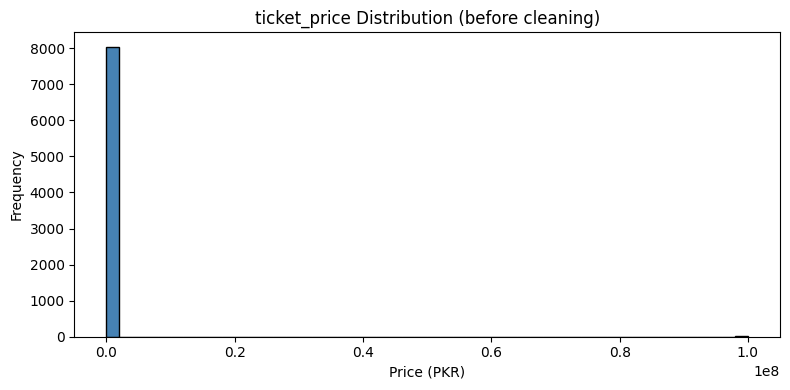

In [22]:
# Visualize target: ticket_price distribution
plt.figure(figsize=(8, 4))
pd.to_numeric(df["ticket_price"], errors="coerce").dropna().plot(kind="hist", bins=50, color="steelblue", edgecolor="black")
plt.title("ticket_price Distribution (before cleaning)")
plt.xlabel("Price (PKR)")
plt.tight_layout()
plt.show()

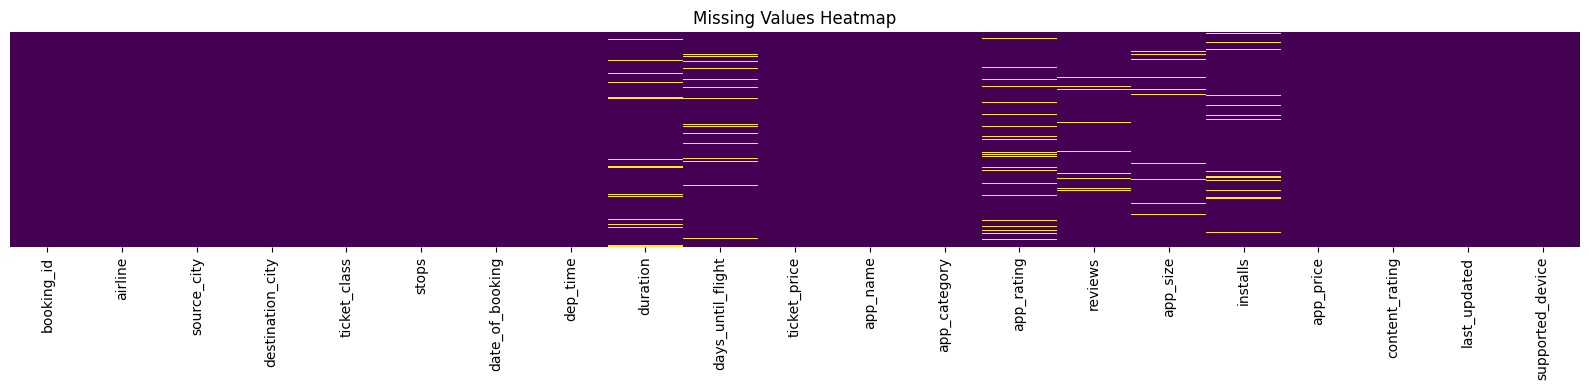

In [23]:
# Missing values heatmap
plt.figure(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

---
## 🧹 Step 3 — Data Cleaning

We go column by column — same approach as flight + playstore notebooks

> **Always work on a copy — never modify the original df**

In [6]:
df_clean = df.copy()

### 3.1 — Remove Duplicates

In [7]:
### 3.1 — Remove Duplicatesprint("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print("After:", df_clean.shape)

After: (8000, 21)


### 3.2 — Fix `airline` (Standardize inconsistent strings)

In [27]:
df_clean.head(5)

,booking_id,airline,source_city,destination_city,ticket_class,stops,date_of_booking,dep_time,duration,days_until_flight,...,app_name,app_category,app_rating,reviews,app_size,installs,app_price,content_rating,last_updated,supported_device
0,BK05365,Emirates,Peshawar,New York,Economy,1 stop,13/03/2022,16:45,10h 10m,NaN,...,Gregory Inc App,Social,1.2,3653704,56.1M,"5,000,000+",$1.49,Everyone,"January 5, 2022",iOS
1,BK06261,FlyJinnah,Karachi,Toronto,Business,1 stop,26/06/2024,00:15,3h 45m,6.0,...,Hutchinson Ltd App,Education,1.5,1886603,680k,"500,000+",0,Everyone,"March 3, 2020",Both
2,BK00274,Turkish Airlines,Quetta,New York,First,1 stop,17/10/2024,21:10,NaN,8.0,...,Chan and Sons App,Education,4.4,2234772,768k,"50,000+",$1.49,Teen,"August 6, 2024",Both
3,BK04916,AirBlue,Peshawar,Dubai,Economy,2 stops,15/09/2022,10:45,3h,79.0,...,Smith-Green App,Lifestyle,2.0,1661045,52.1M,"50,000+",$2.99,Mature 17+,"March 1, 2022",iOS
4,BK06581,AirBlue,Multan,London,Economy,non-stop,15/03/2024,12:00,10h 45m,156.0,...,Bonilla Group App,Social,4.6,1228852,63.8M,"100,000+",0,Teen,"January 1, 2023",iOS


In [ ]:
df_clean["airline"].unique()
# there are many incosistant PIA

<ArrowStringArray>
[        'Emirates',        'FlyJinnah', 'Turkish Airlines',
          'AirBlue',              'PIA',        'SereneAir',
              'pia',              'pIA',            'P.I.A',
           'P.I.A.']
Length: 10, dtype: str

In [8]:
# Lowercase everything then map to correct value
df_clean["airline"] = df_clean["airline"].str.strip().str.lower()

airline_map = {
    "airblue":           "AirBlue",
    "pia":               "PIA",
    "p.i.a":            "PIA",
    "p.i.a.":           "PIA",
    "sereneair":         "SereneAir",
    "flyjinnah":         "FlyJinnah",
    "emirates":          "Emirates",
    "turkish airlines":  "Turkish Airlines"
}

df_clean["airline"] = df_clean["airline"].map(airline_map)

# Verify
df_clean["airline"].value_counts()

airline
Turkish Airlines    1386
Emirates            1352
FlyJinnah           1343
PIA                 1325
SereneAir           1309
AirBlue             1285
Name: count, dtype: int64

### 3.3 — Fix `ticket_class` (Standardize inconsistent strings)

In [30]:
df_clean["ticket_class"].unique()

<ArrowStringArray>
['Economy', 'Business', 'First', 'economy', 'eco', 'ECONOMY']
Length: 6, dtype: str

In [9]:
df_clean["ticket_class"] = df_clean["ticket_class"].str.strip().str.lower()

class_map = {
    "economy": "Economy",
    "eco":     "Economy",
    "business": "Business",
    "first":    "First"
}

df_clean["ticket_class"] = df_clean["ticket_class"].map(class_map)

df_clean["ticket_class"].value_counts()

ticket_class
Economy     5246
Business    2200
First        554
Name: count, dtype: int64

### 3.4 — Fix `stops` (Standardize inconsistent strings + map to numeric)

In [32]:
df_clean["stops"].unique()

<ArrowStringArray>
['1 stop', '2 stops', 'non-stop', '3 stops', 'Non-Stop', 'nonstop',
 'NON-STOP']
Length: 7, dtype: str

In [10]:
# Lowercase + strip first
df_clean["stops"] = df_clean["stops"].str.strip().str.lower()

# Map all variations to standard form
stops_map = {
    "non-stop": "non-stop",
    "nonstop":  "non-stop",
    "1 stop":   "1 stop",
    "2 stops":  "2 stops",
    "3 stops":  "3 stops"
}

df_clean["stops"] = df_clean["stops"].map(stops_map)
df_clean["stops"].value_counts()

stops
1 stop      3164
non-stop    2868
2 stops     1624
3 stops      344
Name: count, dtype: int64

In [11]:
# Now convert stops to numeric like we did in flight dataset
# non-stop = 0, 1 stop = 1, 2 stops = 2, 3 stops = 3

df_clean["stops"] = df_clean["stops"].map({
    "non-stop" : 0,
    "1 stop"   : 1,
    "2 stops"  : 2,
    "3 stops"  : 3
})

df_clean["stops"].value_counts()

stops
1    3164
0    2868
2    1624
3     344
Name: count, dtype: int64

### 3.5 — Fix `date_of_booking` (Split DD/MM/YYYY → Day, Month, Year)

Exact same technique as the flight dataset — split on '/' and extract each part

In [38]:
# See the format
df_clean["date_of_booking"].head(5)

0    13/03/2022
1    26/06/2024
2    17/10/2024
3    15/09/2022
4    15/03/2024
Name: date_of_booking, dtype: str

In [12]:
# Split on '/' — same as: df["Date_of_Journey"].str.split('/').str[0]
df_clean["booking_day"]   = df_clean["date_of_booking"].str.split("/").str[0]
df_clean["booking_month"] = df_clean["date_of_booking"].str.split("/").str[1]
df_clean["booking_year"]  = df_clean["date_of_booking"].str.split("/").str[2]

# Convert to int type
df_clean["booking_day"]   = df_clean["booking_day"].astype("Int8")
df_clean["booking_month"] = df_clean["booking_month"].astype("Int8")
df_clean["booking_year"]  = df_clean["booking_year"].astype("Int16")

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   booking_id         8000 non-null   str    
 1   airline            8000 non-null   str    
 2   source_city        8000 non-null   str    
 3   destination_city   8000 non-null   str    
 4   ticket_class       8000 non-null   str    
 5   stops              8000 non-null   int64  
 6   date_of_booking    8000 non-null   str    
 7   dep_time           8000 non-null   str    
 8   duration           7440 non-null   str    
 9   days_until_flight  7440 non-null   float64
 10  ticket_price       8000 non-null   int64  
 11  app_name           8000 non-null   str    
 12  app_category       8000 non-null   str    
 13  app_rating         7440 non-null   float64
 14  reviews            7600 non-null   str    
 15  app_size           7440 non-null   str    
 16  installs           7440 non-null   

In [13]:
# Drop original date col — we now have numeric breakdown
df_clean.drop("date_of_booking", axis=1, inplace=True)

df_clean[["booking_day", "booking_month", "booking_year"]].head()

,booking_day,booking_month,booking_year
0,13,3,2022
1,26,6,2024
2,17,10,2024
3,15,9,2022
4,15,3,2024


### 3.6 — Fix `dep_time` (Split HH:MM → Dep_Hour, Dep_Min)

Same technique as flight dataset

In [42]:
df_clean["dep_time"].head(5)

0    16:45
1    00:15
2    21:10
3    10:45
4    12:00
Name: dep_time, dtype: str

In [14]:
df_clean["dep_hour"] = df_clean["dep_time"].str.split(":").str[0].astype("int8")
df_clean["dep_min"]  = df_clean["dep_time"].str.split(":").str[1].astype("int8")

df_clean.drop("dep_time", axis=1, inplace=True)

df_clean[["dep_hour", "dep_min"]].head()

,dep_hour,dep_min
0,16,45
1,0,15
2,21,10
3,10,45
4,12,0


### 3.7 — Fix `duration` (Split 'Xh Ym' → Duration_hr, Duration_min)

Same technique as flight dataset — also has NaN and edge cases

In [ ]:
# Check unique values to see edge cases
df_clean["duration"].unique()
# there many inconsistancies

<ArrowStringArray>
['10h 10m',  '3h 45m',       nan,      '3h', '10h 45m',     '16h', '14h 50m',
  '8h 50m',  '4h 50m', '12h 50m',
 ...
 '11h 50m', '18h 55m', '14h 30m',  '9h 15m', '16h 50m',  '3h 25m', '14h 45m',
  '7h 45m', '14h 25m',     '15h']
Length: 163, dtype: str

In [46]:
df_clean["duration"].isnull().sum()

np.int64(560)

In [15]:
# Handle: '2h 30m'   -> hr=2, min=30
#         '5h'        -> hr=5, min=0   (no min part)
#         NaN         -> handle after split

df_clean["duration_hr"]  = df_clean["duration"].str.split(" ").str[0].str.split("h").str[0]
df_clean["duration_min"] = df_clean["duration"].str.split(" ").str[1].str.split("m").str[0]

# duration_min is NaN when format is just '5h' — fill with 0
print("duration_min NaN count:", df_clean["duration_min"].isnull().sum())
df_clean["duration_min"] = df_clean["duration_min"].fillna(0)

# Now convert to numeric
df_clean["duration_hr"]  = pd.to_numeric(df_clean["duration_hr"],  errors="coerce")
df_clean["duration_min"] = pd.to_numeric(df_clean["duration_min"], errors="coerce")

# Fill any remaining NaN with median
df_clean["duration_hr"] = df_clean["duration_hr"].fillna(df_clean["duration_hr"].median())
df_clean["duration_min"] = df_clean["duration_min"].fillna(0)

df_clean["duration_hr"]  = df_clean["duration_hr"].astype("int8")
df_clean["duration_min"] = df_clean["duration_min"].astype("int8")

df_clean.drop("duration", axis=1, inplace=True)

df_clean[["duration_hr", "duration_min"]].head()

duration_min NaN count: 1384


,duration_hr,duration_min
0,10,10
1,3,45
2,10,0
3,3,0
4,10,45


### 3.8 — Fix `reviews` (Handle non-numeric '3.0M', '1.2M', '500K' — like Playstore)

Exact same problem as the Google Playstore notebook

In [51]:
# First check how many non-numeric values exist — same check as Playstore
df_clean["reviews"].str.isnumeric().sum()

np.int64(7570)

In [16]:
# Find the non-numeric rows — same approach as Playstore (df[~df["Reviews"].str.isnumeric()])
non_numeric_reviews = df_clean[~df_clean["reviews"].str.isnumeric() & df_clean["reviews"].notna()]
print(non_numeric_reviews["reviews"].value_counts())

reviews
1.2M    11
500K    11
3.0M     8
Name: count, dtype: int64


In [46]:
# We will make a conversion function — same approach as Playstore's convert_size()
# 3.0M -> 3000000, 500K -> 500000

def convert_reviews(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if "M" in x:
        return float(x.replace("M", "")) * 1_000_000
    elif "K" in x:
        return float(x.replace("K", "")) * 1_000
    else:
        return pd.to_numeric(x, errors="coerce")

df_clean["reviews"] = df_clean["reviews"].apply(convert_reviews)

# Fill NaN with median
df_clean["reviews"] = df_clean["reviews"].fillna(df_clean["reviews"].median(), inplace=True)

df_clean["reviews"] = df_clean["reviews"].astype("int32")

df_clean["reviews"].describe()

count    8.000000e+03
mean     2.499938e+06
std      1.405643e+06
min      9.940000e+02
25%      1.315571e+06
50%      2.509477e+06
75%      3.674024e+06
max      4.999631e+06
Name: reviews, dtype: float64

### 3.9 — Fix `app_size` (Convert '19M' → 19000000, '467k' → 467000 — like Playstore)

In [48]:
# Same function as Playstore convert_size()
def convert_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if "M" in x:
        return float(x.replace("M", "")) * 1_000_000
    elif "k" in x:
        return float(x.replace("k", "")) * 1_000
    return np.nan

df_clean["app_size"] = df_clean["app_size"].apply(convert_size)

# Check NaN count after conversion
print("NaN in app_size:", df_clean["app_size"].isnull().sum())

# Fill NaN with mean — same as Playstore
df_clean["app_size"] = df_clean["app_size"].fillna(df_clean["app_size"].mean())
df_clean["app_size"] = df_clean["app_size"].astype("float32")

df_clean["app_size"].describe()

NaN in app_size: 559


count        8000.0
mean     35178964.0
std      31886426.0
min        100000.0
25%        894000.0
50%      33950000.0
75%      62125000.0
max      99000000.0
Name: app_size, dtype: float64

### 3.10 — Fix `installs` (Remove '+' and ',' — like Playstore)

In [18]:
df_clean["installs"].unique()

<ArrowStringArray>
[ '5,000,000+',    '500,000+',     '50,000+',    '100,000+',      '1,000+',
           nan,     '10,000+',      '5,000+',  '1,000,000+', '10,000,000+']
Length: 10, dtype: str

In [19]:
# Exact same approach as Playstore: remove special chars then convert
# chars to remove: '+' and ','

chars_to_remove = ["+", ","]

for char in chars_to_remove:
    df_clean["installs"] = df_clean["installs"].astype(str).str.replace(char, "", regex=False)

# Some NaN might have become 'nan' string after above — fix that
df_clean["installs"] = df_clean["installs"].replace("nan", np.nan)

# Convert to numeric
df_clean["installs"] = pd.to_numeric(df_clean["installs"], errors="coerce")

# Fill NaN with median
df_clean["installs"] = df_clean["installs"].fillna(df_clean["installs"].median())
df_clean["installs"] = df_clean["installs"].astype("int64")

df_clean["installs"].value_counts().head()

installs
50000     2029
100000    1487
10000     1130
500000    1097
5000       768
Name: count, dtype: int64

### 3.11 — Fix `app_price` (Remove '$' — like Playstore)

In [20]:
### 3.11 — Fix `app_price` (Remove '$' — like Playstore)
# Remove '$' sign — same approach as Playstore removing '+' '$' ','
df_clean["app_price"] = df_clean["app_price"].str.replace("$", "", regex=False)
df_clean["app_price"] = df_clean["app_price"].astype("float32")

df_clean["app_price"].value_counts()

app_price
0.00    5984
0.99     811
2.99     500
1.49     471
4.99     234
Name: count, dtype: int64

### 3.12 — Fix `last_updated` (Parse datetime → Day, Month, Year — like Playstore)

In [21]:
df_clean["last_updated"].head()

0    January 5, 2022
1      March 3, 2020
2     August 6, 2024
3      March 1, 2022
4    January 1, 2023
Name: last_updated, dtype: str

In [23]:
# pd.to_datetime parses 'January 15, 2023' cleanly
df_clean["last_updated"] = pd.to_datetime(df_clean["last_updated"])



# Now use .dt to extract Day, Month, Year — same as Playstore
df_clean["update_day"]   = df_clean["last_updated"].dt.day
df_clean["update_month"] = df_clean["last_updated"].dt.month
df_clean["update_year"]  = df_clean["last_updated"].dt.year

df_clean.drop("last_updated", axis=1, inplace=True)

df_clean[["update_day", "update_month", "update_year"]].head()

,update_day,update_month,update_year
0,5,1,2022
1,3,3,2020
2,6,8,2024
3,1,3,2022
4,1,1,2023


### 3.13 — Fix `ticket_price` (Remove outliers — same as Playstore Price outlier approach)

In [24]:
### 3.13 — Fix `ticket_price` (Remove outliers — same as Playstore Price outlier approach)
# Convert to numeric first (some rows had bad string values)
df_clean["ticket_price"] = pd.to_numeric(df_clean["ticket_price"], errors="coerce")
df_clean["ticket_price"].describe()

count    8.000000e+03
mean     1.715517e+05
std      3.532118e+06
min     -5.000000e+02
25%      1.974225e+04
50%      2.816950e+04
75%      7.368025e+04
max      1.000000e+08
Name: ticket_price, dtype: float64

In [27]:
# Find rows with impossible prices
df_clean[ (df_clean["ticket_price"] <= 0) | (df_clean["ticket_price"] > 1_000_000) ].head(2)

,booking_id,airline,source_city,destination_city,ticket_class,stops,days_until_flight,ticket_price,app_name,app_category,...,booking_day,booking_month,booking_year,dep_hour,dep_min,duration_hr,duration_min,update_day,update_month,update_year
164,BK04473,Emirates,Islamabad,Istanbul,Business,0,49.0,-500,Miller Ltd App,Finance,...,20,7,2024,4,50,3,10,28,12,2021
441,BK02373,SereneAir,Multan,Kuala Lumpur,Economy,1,NaN,0,Hampton-Snyder App,Business,...,2,9,2023,21,10,17,0,15,11,2022


In [36]:
# Replace outliers with NaN

df_clean.loc[
    (df_clean["ticket_price"] <= 0) |
    (df_clean["ticket_price"] > 100000),
    "ticket_price"
] = np.nan

# Check remaining NaNs
print("NaNs after outlier removal:", df_clean["ticket_price"].isna().sum())

# Fill with median
median_price = df_clean["ticket_price"].median()
df_clean["ticket_price"] = df_clean["ticket_price"].fillna(median_price)

# Check again
print("NaNs after fill:", df_clean["ticket_price"].isna().sum())

# Convert to integer
df_clean["ticket_price"] = df_clean["ticket_price"].astype("int32")

NaNs after outlier removal: 590
NaNs after fill: 0


### 3.14 — Fix `app_rating` (Handle NaN + outliers outside 1.0–5.0)

In [37]:
### 3.14 — Fix `app_rating` (Handle NaN + outliers outside 1.0–5.0)
df_clean["app_rating"] = pd.to_numeric(df_clean["app_rating"], errors="coerce")
df_clean["app_rating"].describe()

count    7440.000000
mean        3.009973
std         1.162892
min        -1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: app_rating, dtype: float64

In [39]:
# Find outliers outside 1.0 to 5.0
df_clean[ (df_clean["app_rating"] < 1.0) | (df_clean["app_rating"] > 5.0) ].head(5)

,booking_id,airline,source_city,destination_city,ticket_class,stops,days_until_flight,ticket_price,app_name,app_category,...,booking_day,booking_month,booking_year,dep_hour,dep_min,duration_hr,duration_min,update_day,update_month,update_year
180,BK07577,SereneAir,Islamabad,New York,Economy,0,117.0,20547,"Monroe, Knight and Herrera App",Lifestyle,...,19,1,2021,13,15,7,20,15,1,2020
1017,BK03254,PIA,Islamabad,Toronto,Economy,0,147.0,63682,Carrillo Inc App,Lifestyle,...,14,12,2024,17,50,14,0,20,4,2023
1533,BK07680,Emirates,Islamabad,London,Economy,1,170.0,30655,Phillips-Bennett App,Social,...,10,11,2024,14,10,10,50,23,12,2022
1617,BK03668,Emirates,Karachi,London,Economy,2,87.0,26958,Boyd and Sons App,Entertainment,...,7,6,2021,0,15,13,20,24,6,2024
1650,BK07747,Emirates,Islamabad,Toronto,Economy,0,98.0,91856,Roy PLC App,Health,...,15,8,2024,14,50,6,45,27,9,2020


In [40]:
# Replace bad ratings with NaN then fill with mean
df_clean.loc[
    (df_clean["app_rating"] < 1.0) | (df_clean["app_rating"] > 5.0),
    "app_rating"
] = np.nan

df_clean["app_rating"] = df_clean["app_rating"].fillna(df_clean["app_rating"].mean(), inplace=True)
df_clean["app_rating"] = df_clean["app_rating"].round(1)

df_clean["app_rating"].describe()

count    8000.000000
mean        3.008400
std         1.109409
min         1.000000
25%         2.100000
50%         3.000000
75%         3.900000
max         5.000000
Name: app_rating, dtype: float64

### 3.15 — Fix `days_until_flight` (Fill NaN)

In [42]:
df_clean["days_until_flight"] = pd.to_numeric(df_clean["days_until_flight"], errors="coerce")
df_clean["days_until_flight"] = df_clean["days_until_flight"].fillna(df_clean["days_until_flight"].median(), inplace=True)
df_clean["days_until_flight"] = df_clean["days_until_flight"].astype("int16")

df_clean["days_until_flight"].describe()

count    8000.000000
mean       90.081000
std        50.060548
min         1.000000
25%        48.000000
50%        90.000000
75%       133.000000
max       179.000000
Name: days_until_flight, dtype: float64

In [43]:
# booking_id and app_name are identifiers — no value for ML model
df_clean.drop(["booking_id", "app_name"], axis=1, inplace=True)

df_clean.head()

,airline,source_city,destination_city,ticket_class,stops,days_until_flight,ticket_price,app_category,app_rating,reviews,...,booking_day,booking_month,booking_year,dep_hour,dep_min,duration_hr,duration_min,update_day,update_month,update_year
0,Emirates,Peshawar,New York,Economy,1,90,16565,Social,1.2,3653704,...,13,3,2022,16,45,10,10,5,1,2022
1,FlyJinnah,Karachi,Toronto,Business,1,6,75670,Education,1.5,1886603,...,26,6,2024,0,15,3,45,3,3,2020
2,Turkish Airlines,Quetta,New York,First,1,8,26727,Education,4.4,2234772,...,17,10,2024,21,10,10,0,6,8,2024
3,AirBlue,Peshawar,Dubai,Economy,2,79,16949,Lifestyle,2.0,1661045,...,15,9,2022,10,45,3,0,1,3,2022
4,AirBlue,Multan,London,Economy,0,156,31705,Social,4.6,1228852,...,15,3,2024,12,0,10,45,1,1,2023


In [49]:
# Should be zero everywhere now
df_clean.isnull().sum()

airline              0
source_city          0
destination_city     0
ticket_class         0
stops                0
days_until_flight    0
ticket_price         0
app_category         0
app_rating           0
reviews              0
app_size             0
installs             0
app_price            0
content_rating       0
supported_device     0
booking_day          0
booking_month        0
booking_year         0
dep_hour             0
dep_min              0
duration_hr          0
duration_min         0
update_day           0
update_month         0
update_year          0
dtype: int64

In [53]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   airline            8000 non-null   str    
 1   source_city        8000 non-null   str    
 2   destination_city   8000 non-null   str    
 3   ticket_class       8000 non-null   str    
 4   stops              8000 non-null   int64  
 5   days_until_flight  8000 non-null   int16  
 6   ticket_price       8000 non-null   int32  
 7   app_category       8000 non-null   str    
 8   app_rating         8000 non-null   float64
 9   reviews            8000 non-null   int32  
 10  app_size           8000 non-null   float32
 11  installs           8000 non-null   int64  
 12  app_price          8000 non-null   float32
 13  content_rating     8000 non-null   str    
 14  supported_device   8000 non-null   str    
 15  booking_day        8000 non-null   Int8   
 16  booking_month      8000 non-null   

---
## ⚙️ Step 4 — Feature Engineering

In [54]:
# 4.1 — total_duration_in_minutes
# One clean number instead of two separate hr/min cols

df_clean["total_duration_min"] = df_clean["duration_hr"] * 60 + df_clean["duration_min"]

df_clean[["duration_hr", "duration_min", "total_duration_min"]].head()

,duration_hr,duration_min,total_duration_min
0,10,10,98
1,3,45,-31
2,10,0,88
3,3,0,-76
4,10,45,-123


In [55]:
# 4.2 — is_international
# If source and destination are different countries it is international
# Here all source_city are Pakistan and all destination_city are foreign

df_clean["is_international"] = 1  # all routes in this dataset are international
# If you had domestic routes, you would compare source vs destination city country

In [ ]:
# 4.3 — booking_lead_time_group — bin days_until_flight
# Last minute (0-7), Short Notice (8-30), Planned (31-90), Early Bird (91-180)

df_clean["lead_time_group"] = pd.cut(
    df_clean["days_until_flight"],
    bins=[0, 7, 30, 90, 180],
    labels=["Last Minute", "Short Notice", "Planned", "Early Bird"]
)


df_clean["lead_time_group"].value_counts()

lead_time_group
Early Bird      3684
Planned         3051
Short Notice     989
Last Minute      276
Name: count, dtype: int64

In [57]:
# 4.4 — price_per_hour_of_flight
# How much does each hour of flight cost?

df_clean["price_per_hour"] = (
    df_clean["ticket_price"] / (df_clean["total_duration_min"] / 60)
).round(2)

# Replace inf (if duration is 0) with 0
df_clean["price_per_hour"] = df_clean["price_per_hour"].replace([np.inf, -np.inf], 0)

df_clean[["ticket_price", "total_duration_min", "price_per_hour"]].head()

,ticket_price,total_duration_min,price_per_hour
0,16565,98,10141.84
1,75670,-31,-146458.06
2,26727,88,18222.95
3,16949,-76,-13380.79
4,31705,-123,-15465.85


In [58]:
# 4.5 — app_engagement_score
# A single score combining rating and log of installs + reviews

import numpy as np

df_clean["engagement_score"] = (
    df_clean["app_rating"] * 0.4 +
    np.log1p(df_clean["installs"]) * 0.4 +
    np.log1p(df_clean["reviews"]) * 0.2
).round(3)

df_clean["engagement_score"].describe()

count    8000.000000
mean        8.569978
std         0.972540
min         5.169000
25%         7.902000
50%         8.528500
75%         9.201000
max        11.443000
Name: engagement_score, dtype: float64

In [59]:
# 4.6 — drop cols now absorbed into new features
# total_duration_min replaces duration_hr and duration_min
# keep duration_hr/min for reference or drop for cleaner dataset

# keeping them for now — you can drop if model training shows redundancy
df_clean.head()

,airline,source_city,destination_city,ticket_class,stops,days_until_flight,ticket_price,app_category,app_rating,reviews,...,duration_hr,duration_min,update_day,update_month,update_year,total_duration_min,is_international,lead_time_group,price_per_hour,engagement_score
0,Emirates,Peshawar,New York,Economy,1,90,16565,Social,1.2,3653704,...,10,10,5,1,2022,98,1,Planned,10141.84,9.672
1,FlyJinnah,Karachi,Toronto,Business,1,6,75670,Education,1.5,1886603,...,3,45,3,3,2020,-31,1,Last Minute,-146458.06,8.739
2,Turkish Airlines,Quetta,New York,First,1,8,26727,Education,4.4,2234772,...,10,0,6,8,2024,88,1,Short Notice,18222.95,9.012
3,AirBlue,Peshawar,Dubai,Economy,2,79,16949,Lifestyle,2.0,1661045,...,3,0,1,3,2022,-76,1,Planned,-13380.79,7.993
4,AirBlue,Multan,London,Economy,0,156,31705,Social,4.6,1228852,...,10,45,1,1,2023,-123,1,Early Bird,-15465.85,9.249


---
## 🔢 Step 5 — Encoding Categorical Columns

| Column | Method | Reason |
|--------|--------|--------|
| `supported_device` | Label Encoding | Binary-like: Android/iOS/Both |
| `airline` | Target Guided Ordinal | High cardinality, no natural order |
| `app_category` | One Hot Encoding | Nominal, no order |
| `source_city` | One Hot Encoding | Nominal, no order |
| `destination_city` | One Hot Encoding | Nominal, no order |
| `ticket_class` | Ordinal Encoding | Natural order: Economy < Business < First |
| `content_rating` | Ordinal Encoding | Natural order: Everyone < Teen < Mature < Adults |
| `lead_time_group` | Ordinal Encoding | Natural order: Last Minute < Short Notice < Planned < Early Bird |


In [60]:
df_clean.head()

,airline,source_city,destination_city,ticket_class,stops,days_until_flight,ticket_price,app_category,app_rating,reviews,...,duration_hr,duration_min,update_day,update_month,update_year,total_duration_min,is_international,lead_time_group,price_per_hour,engagement_score
0,Emirates,Peshawar,New York,Economy,1,90,16565,Social,1.2,3653704,...,10,10,5,1,2022,98,1,Planned,10141.84,9.672
1,FlyJinnah,Karachi,Toronto,Business,1,6,75670,Education,1.5,1886603,...,3,45,3,3,2020,-31,1,Last Minute,-146458.06,8.739
2,Turkish Airlines,Quetta,New York,First,1,8,26727,Education,4.4,2234772,...,10,0,6,8,2024,88,1,Short Notice,18222.95,9.012
3,AirBlue,Peshawar,Dubai,Economy,2,79,16949,Lifestyle,2.0,1661045,...,3,0,1,3,2022,-76,1,Planned,-13380.79,7.993
4,AirBlue,Multan,London,Economy,0,156,31705,Social,4.6,1228852,...,10,45,1,1,2023,-123,1,Early Bird,-15465.85,9.249


### 5.1 — Label Encoding (`supported_device`)

In [61]:
le = LabelEncoder()

df_clean["supported_device"] = le.fit_transform(df_clean["supported_device"])

print("Classes learned:", le.classes_)  # see what each number maps to
df_clean[["supported_device"]].value_counts()

Classes learned: ['Android' 'Both' 'iOS']


supported_device
2                   2720
1                   2657
0                   2623
Name: count, dtype: int64

### 5.2 — Ordinal Encoding (`ticket_class`, `content_rating`, `lead_time_group`)

In [62]:
# ticket_class: Economy < Business < First
class_order = [["Economy", "Business", "First"]]

oe_class = OrdinalEncoder(categories=class_order)
df_clean["ticket_class"] = oe_class.fit_transform(df_clean[["ticket_class"]])

print("ticket_class order:", oe_class.categories_)

ticket_class order: [array(['Economy', 'Business', 'First'], dtype=object)]


In [63]:
# content_rating: Everyone < Teen < Mature 17+ < Adults Only 18+
rating_order = [["Everyone", "Teen", "Mature 17+", "Adults Only 18+"]]

oe_rating = OrdinalEncoder(categories=rating_order)
df_clean["content_rating"] = oe_rating.fit_transform(df_clean[["content_rating"]])

print("content_rating order:", oe_rating.categories_)

content_rating order: [array(['Everyone', 'Teen', 'Mature 17+', 'Adults Only 18+'], dtype=object)]


In [64]:
# lead_time_group: Last Minute < Short Notice < Planned < Early Bird
lead_order = [["Last Minute", "Short Notice", "Planned", "Early Bird"]]

oe_lead = OrdinalEncoder(categories=lead_order)
df_clean["lead_time_group"] = oe_lead.fit_transform(df_clean[["lead_time_group"]])

print("lead_time_group order:", oe_lead.categories_)

lead_time_group order: [array(['Last Minute', 'Short Notice', 'Planned', 'Early Bird'],
      dtype=object)]


### 5.3 — Target Guided Ordinal Encoding (`airline`)

Airlines have no natural order — let mean ticket_price decide the rank

In [65]:
# Step 1: Compute mean ticket_price per airline
airline_mean = df_clean.groupby("airline")["ticket_price"].mean()
print(airline_mean.sort_values())

airline
FlyJinnah           36828.065525
AirBlue             37292.701946
PIA                 37303.990943
Turkish Airlines    37444.775613
Emirates            38026.848373
SereneAir           38127.746371
Name: ticket_price, dtype: float64


In [66]:
# Step 2: Rank by mean price — lowest mean = rank 1
airline_rank = airline_mean.rank(method="dense").astype(int)
print("\nAirline Rank Map:")
print(airline_rank)


Airline Rank Map:
airline
AirBlue             2
Emirates            5
FlyJinnah           1
PIA                 3
SereneAir           6
Turkish Airlines    4
Name: ticket_price, dtype: int64


In [67]:
# Step 3: Map rank back to df
df_clean["airline"] = df_clean["airline"].map(airline_rank)

df_clean[["airline"]].value_counts()

airline
4          1386
5          1352
1          1343
3          1325
6          1309
2          1285
Name: count, dtype: int64

### 5.4 — One Hot Encoding (`app_category`, `source_city`, `destination_city`)

In [68]:
# pd.get_dummies — same as what you have been using in your notebooks
df_clean = pd.get_dummies(
    df_clean,
    columns=["app_category", "source_city", "destination_city"],
    drop_first=True,   # avoid dummy variable trap
    dtype=int
)

# See new columns created
df_clean.columns.tolist()

['airline',
 'ticket_class',
 'stops',
 'days_until_flight',
 'ticket_price',
 'app_rating',
 'reviews',
 'app_size',
 'installs',
 'app_price',
 'content_rating',
 'supported_device',
 'booking_day',
 'booking_month',
 'booking_year',
 'dep_hour',
 'dep_min',
 'duration_hr',
 'duration_min',
 'update_day',
 'update_month',
 'update_year',
 'total_duration_min',
 'is_international',
 'lead_time_group',
 'price_per_hour',
 'engagement_score',
 'app_category_Education',
 'app_category_Entertainment',
 'app_category_Finance',
 'app_category_Health',
 'app_category_Lifestyle',
 'app_category_Social',
 'app_category_Travel',
 'source_city_Karachi',
 'source_city_Lahore',
 'source_city_Multan',
 'source_city_Peshawar',
 'source_city_Quetta',
 'destination_city_Istanbul',
 'destination_city_Kuala Lumpur',
 'destination_city_London',
 'destination_city_New York',
 'destination_city_Toronto']

---
## 📦 Step 6 — Outlier Removal on `ticket_price` (IQR Method)

Same approach as the flight dataset Price outlier removal using 5 Number Summary

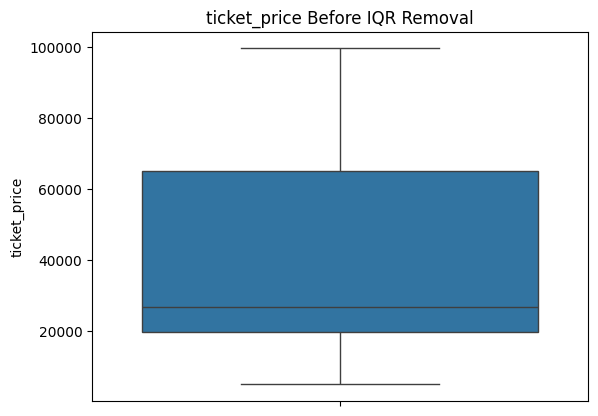

In [69]:
sns.boxplot(df_clean["ticket_price"])
plt.title("ticket_price Before IQR Removal")
plt.show()

In [70]:
Q1 = df_clean["ticket_price"].quantile(0.25)
Q3 = df_clean["ticket_price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

df_clean = df_clean[
    (df_clean["ticket_price"] >= lower_limit) &
    (df_clean["ticket_price"] <= upper_limit)
]

print("\nShape after IQR removal:", df_clean.shape)

Lower limit: -48034.875
Upper limit: 132882.125

Shape after IQR removal: (8000, 44)


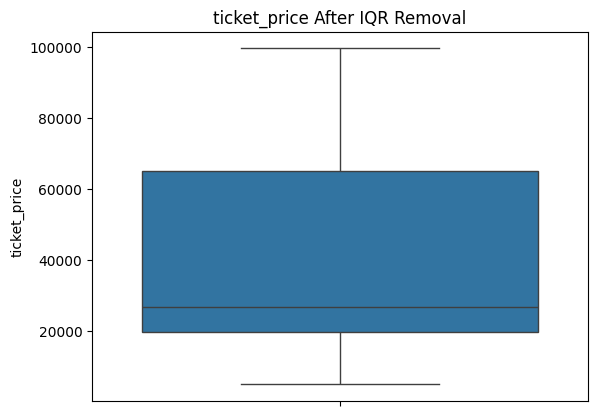

In [71]:
sns.boxplot(df_clean["ticket_price"])
plt.title("ticket_price After IQR Removal")
plt.show()

---
## ✅ Step 7 — Final Check + X, y Split

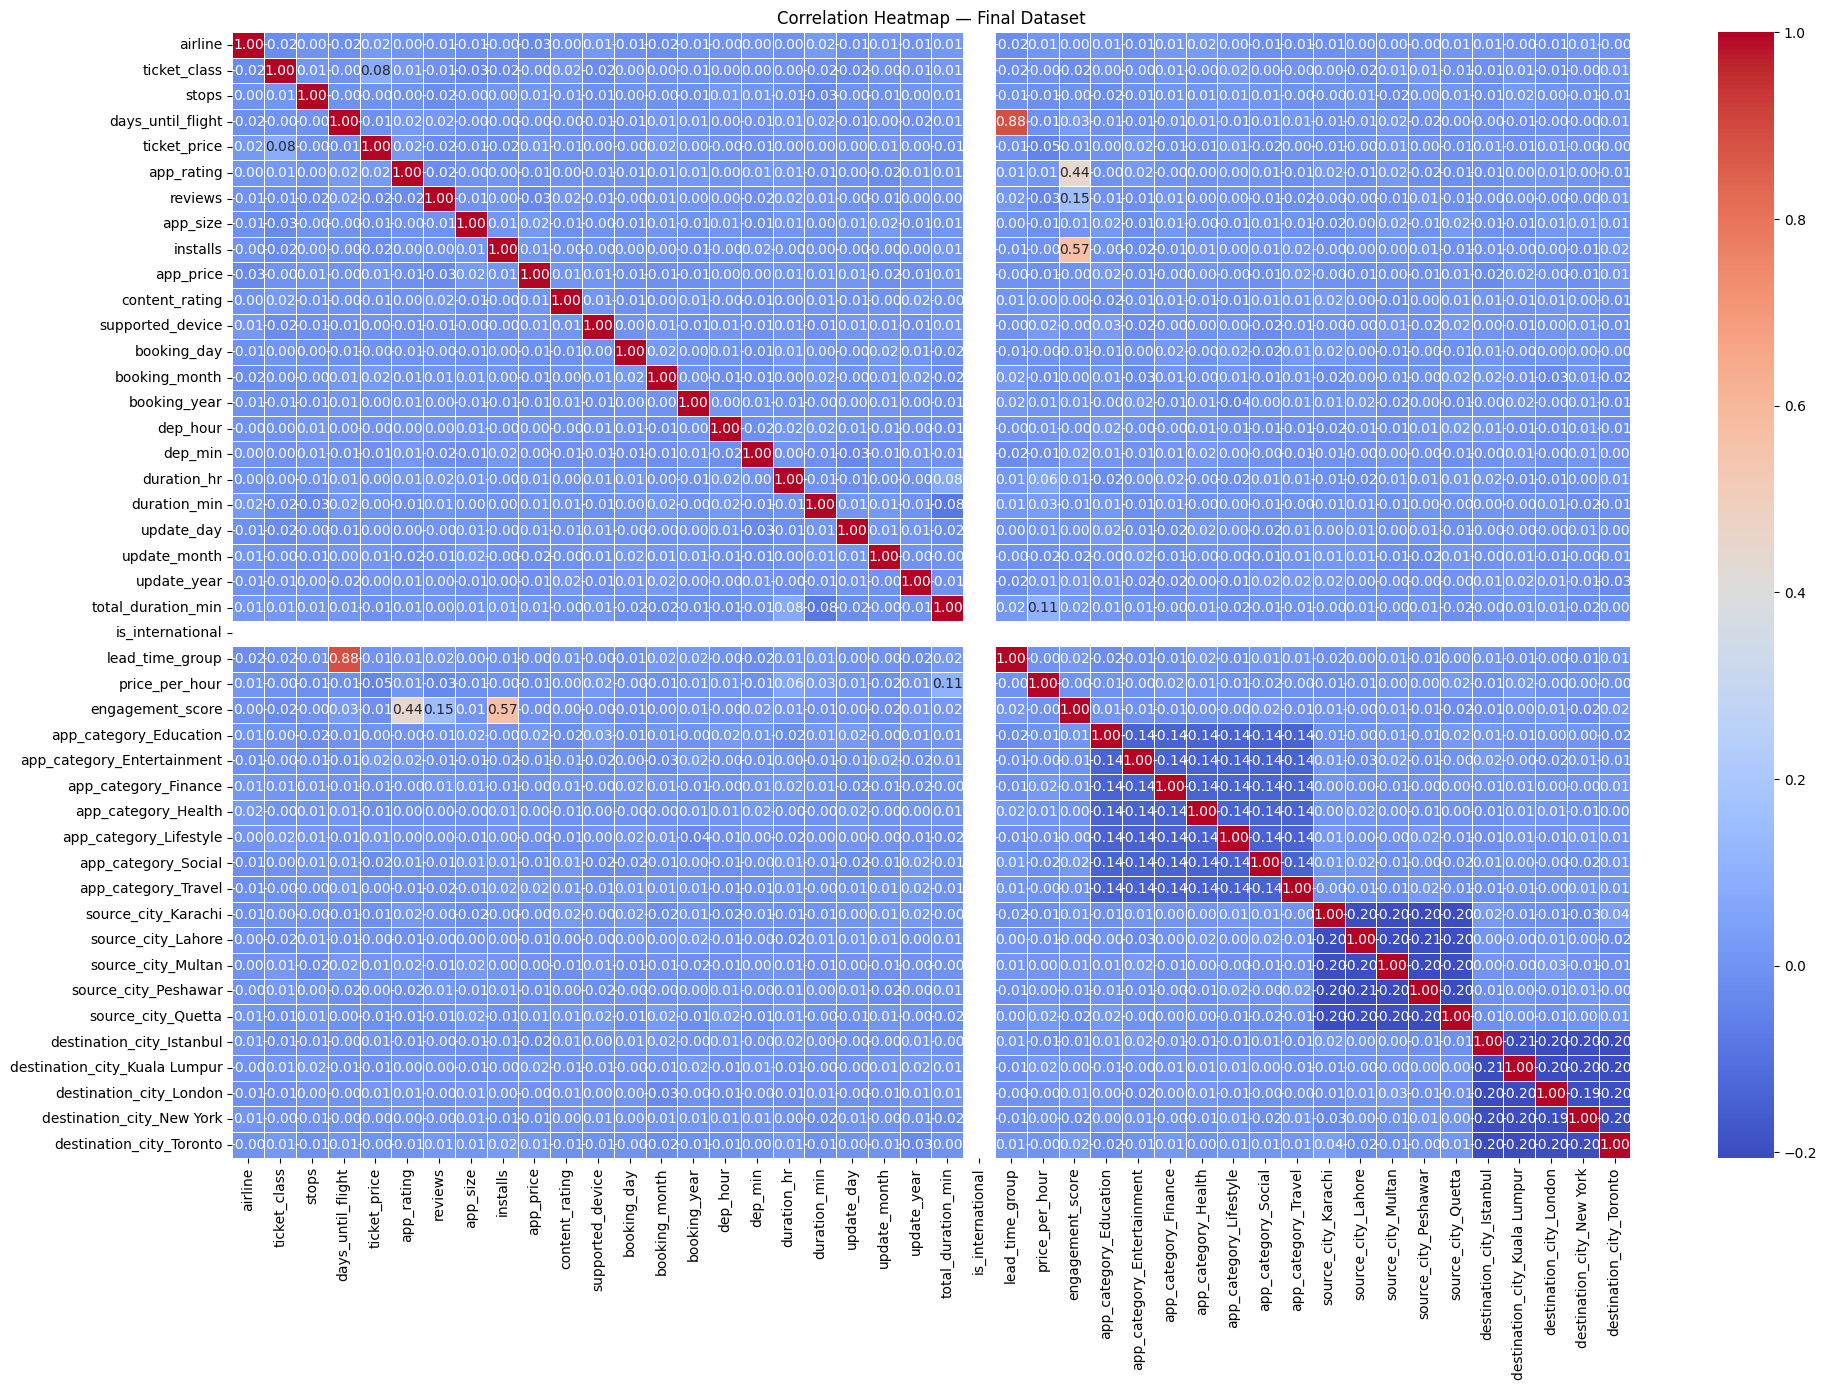

In [72]:
# Correlation heatmap — see which features relate to ticket_price
plt.figure(figsize=(20, 14))
sns.heatmap(
    df_clean.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.4
)
plt.title("Correlation Heatmap — Final Dataset")
plt.tight_layout()
plt.show()

In [73]:
# Split into X (features) and y (target)
X = df_clean.drop("ticket_price", axis=1)
y = df_clean["ticket_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample y values:")
print(y.head())

X shape: (8000, 43)
y shape: (8000,)

Sample y values:
0    16565
1    75670
2    26727
3    16949
4    31705
Name: ticket_price, dtype: int32


---

## 🎯 Summary — What We Did Column by Column

| Column | Action |
|--------|--------|
| `booking_id`, `app_name` | Dropped — identifier columns |
| `airline` | Standardized strings → Target Guided Ordinal Encoding |
| `ticket_class` | Standardized strings → Ordinal Encoding |
| `stops` | Standardized strings → mapped to numeric (0/1/2/3) |
| `date_of_booking` | Split DD/MM/YYYY → booking_day, booking_month, booking_year |
| `dep_time` | Split HH:MM → dep_hour, dep_min |
| `duration` | Split Xh Ym → duration_hr, duration_min + filled NaN |
| `reviews` | Converted 3.0M/500K → numbers (Playstore technique) |
| `app_size` | Converted M/k → numbers (Playstore technique) |
| `installs` | Removed +, commas → int (Playstore technique) |
| `app_price` | Removed $ → float (Playstore technique) |
| `last_updated` | pd.to_datetime → update_day, update_month, update_year |
| `ticket_price` | Removed outliers → IQR method (flight technique) |
| `app_rating` | Removed outliers outside 1-5 → filled NaN |
| `days_until_flight` | Filled NaN with median |
| `supported_device` | Label Encoding |
| `content_rating` | Ordinal Encoding |
| `lead_time_group` | Ordinal Encoding |
| `app_category`, `source_city`, `destination_city` | One Hot Encoding |
| **Feature Engineering** | total_duration_min, lead_time_group, price_per_hour, engagement_score |
